In [20]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


bids_folder_ex = '/Volumes/mrenkeED/data/ds-stressrisk'
path_models = op.join(bids_folder_ex,'derivatives','hierachical_models')

smoothed = False
mask_sep_name =  'ses1' #'sessep' #

pars_fn = f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/encoding_params_smoothed-{smoothed}_mask-{mask_sep_name}.csv'     

In [18]:
df = pd.read_csv(pars_fn)
df['mu_norm'] = np.round(np.exp(df['mu']))

In [5]:
#bins = np.logspace(0,10,num=5, base=2.718)
#pars['mu_bin'] = pd.cut(pars['mu'], bins)

bins = np.concatenate([np.arange(0, 20, 5), np.arange(20, 50, 10), np.arange(50, 100, 20)]) # np.arange(0, 100, 5) #bins = np.arange(0, 25, 5)
df['mu_bin'] = pd.cut(df['mu_norm'], bins, labels=False) # labels=False implies you just want the bins back.

mean_pars = df.groupby(['subject', 'session','mu_bin']).mean().set_index('group', append=True)


Text(0.5, 1.0, 'group 1')

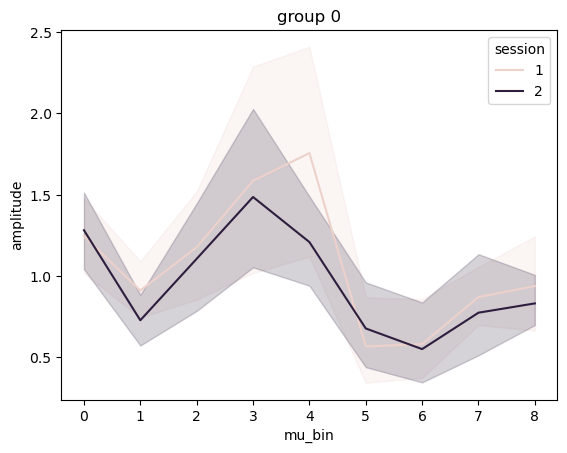

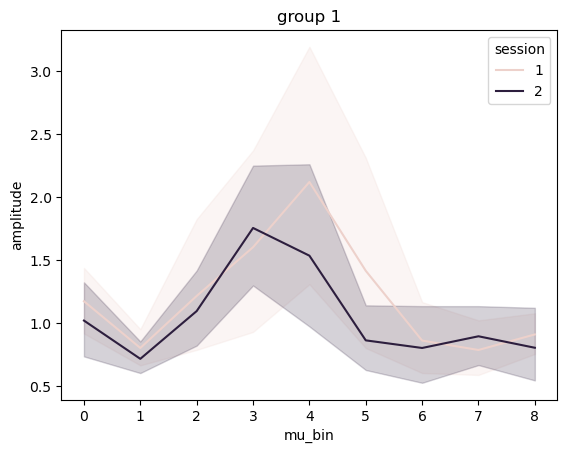

In [6]:
sns.lineplot(data=mean_pars.xs(0,0,'group').reset_index(), x='mu_bin', y='amplitude', hue='session') #, col='group') # mu_bin does not work as x !
plt.title('group 0')
plt.figure()
sns.lineplot(data=mean_pars.xs(1,0,'group').reset_index(), x='mu_bin', y='amplitude', hue='session') #, col='group') # mu_bin does not work as x !
plt.title('group 1')


Text(0.5, 1.0, 'session 2')

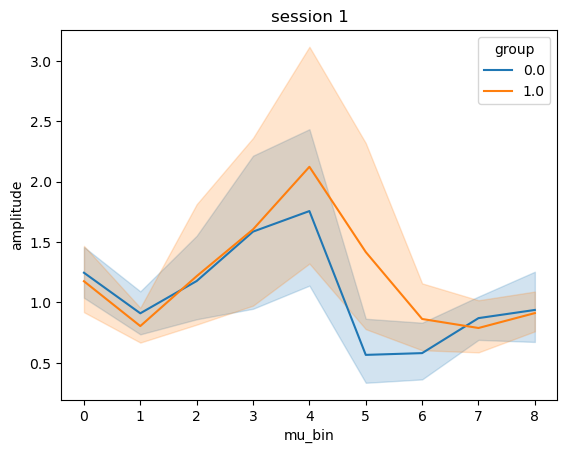

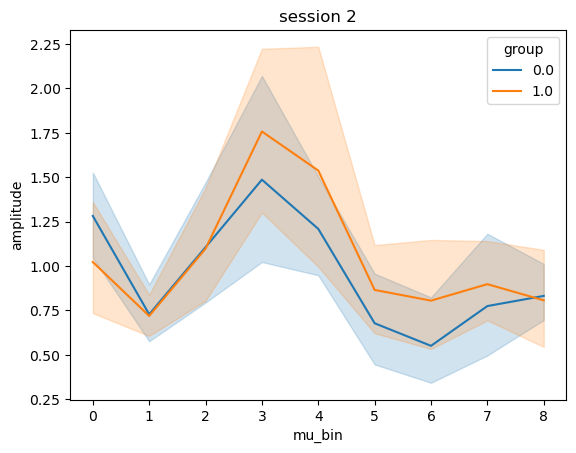

In [7]:
sns.lineplot(data=mean_pars.xs(1,0,'session').reset_index(), x='mu_bin', y='amplitude', hue='group') #, col='group') # mu_bin does not work as x !
plt.title('session 1')
plt.figure()
sns.lineplot(data=mean_pars.xs(2,0,'session').reset_index(), x='mu_bin', y='amplitude', hue='group') #, col='group') # mu_bin does not work as x !
plt.title('session 2')


Text(0, 0.5, 'amplitude')

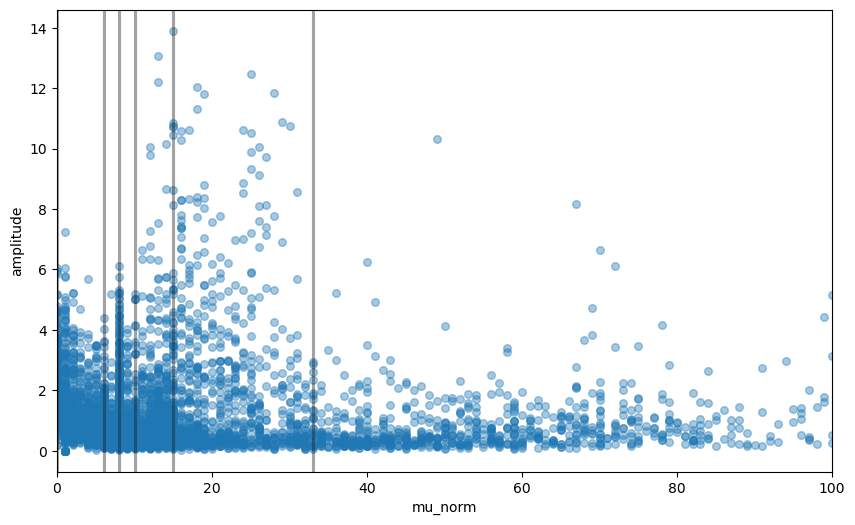

In [140]:
# visualize data 

num_knots = 7
knots = np.quantile(df['mu_norm'], np.linspace(0, 1, num_knots))

def plot_scatter(data, figsize=(10, 6)):
    _, ax = plt.subplots(figsize=figsize)
    ax.scatter(data["mu_norm"], data["amplitude"], alpha=0.4, s=30)
    plt.xlim(0,100)
    return ax
def plot_knots(knots, ax):
    for knot in knots:
        ax.axvline(knot, color="0.1", alpha=0.4)
    return ax

ax = plot_scatter(df)
sns.set_context('talk')
plot_knots(knots, ax)
plt.xlabel('mu_norm')
plt.ylabel('amplitude')

In [19]:
# fit
import bambi as bmb

reg = 'mu_norm'
spec = '_mu-norm<110'

temp = df[df['mu_norm'] < 110] # filter out too large mus # .dropna(axis=0)
model = bmb.Model(f'amplitude ~ bs({reg}, df=7)*C(session)*C(group)+(bs({reg}, df=7)*C(session)|subject)', data=temp)
idata = model.fit()

idata.to_netcdf(op.join(path_models,f'encoding_params_amplitude-mu_spline-regression{spec}_smoothed-{smoothed}_mask-{mask_sep_name}.netcdf')

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, bs(mu_norm, df = 7), C(session), bs(mu_norm, df = 7):C(session), C(group), bs(mu_norm, df = 7):C(group), C(session):C(group), bs(mu_norm, df = 7):C(session):C(group), 1|subject_sigma, 1|subject_offset, bs(mu_norm, df = 7)|subject_sigma, bs(mu_norm, df = 7)|subject_offset, C(session)|subject_sigma, C(session)|subject_offset, bs(mu_norm, df = 7):C(session)|subject_sigma, bs(mu_norm, df = 7):C(session)|subject_offset, amplitude_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 619 seconds.


'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/hierachical_models/encoding_params_amplitude-mu_spline-regression_mu-norm<110_smoothed-False_mask-ses1.netcdf'

In [22]:
# load trace
import arviz as az
import bambi as bmb

reg = 'mu_norm'
spec = '_mu-norm<110'

model = bmb.Model(f'amplitude ~ bs({reg}, df=7)*C(session)*C(group)+(bs({reg}, df=7)*C(session)|subject)', data=df[df['mu_norm'] < 110])

traces = az.from_netcdf(op.join(path_models,f'encoding_params_amplitude-mu_spline-regression{spec}_smoothed-{smoothed}_mask-{mask_sep_name}.netcdf'))

#traces.posterior['bs(mu_norm * session * group, knots = iknots, intercept = True)']
posterior_stacked = az.extract(traces)
list(posterior_stacked.coords)
# mu_ses_gr_int = posterior_stacked['bs(mu_norm, df = 7):C(session):C(group)'].to_dataframe()


['bs(mu_norm, df = 7)_dim',
 'C(session)_dim',
 'bs(mu_norm, df = 7):C(session)_dim',
 'C(group)_dim',
 'bs(mu_norm, df = 7):C(group)_dim',
 'C(session):C(group)_dim',
 'bs(mu_norm, df = 7):C(session):C(group)_dim',
 'subject__factor_dim',
 'bs(mu_norm, df = 7)__expr_dim',
 'C(session)__expr_dim',
 'bs(mu_norm, df = 7):C(session)__expr_dim',
 'sample',
 'chain',
 'draw']

In [23]:
test_x = pd.Series(np.linspace(0, 110, 100), name='mu_norm')
categories1 = pd.Series([1,2], name='session')
categories2 = pd.Series([0,1], name='group')

test_data = pd.MultiIndex.from_product([test_x, categories1,categories2]).to_frame()
test_data.head(2)

mu_norm  session  group
mu_norm session group                         
0.0     1       0          0.0        1      0
                1          0.0        1      1

In [24]:
predictions = model.predict(traces, data=test_data, include_group_specific=False, inplace=False)

predictions = predictions.posterior['amplitude_mean'].to_dataframe().unstack(['chain', 'draw'])
predictions.index = test_data.index
predictions = predictions.stack(['chain', 'draw'])

In [25]:
import arviz as az
def get_hdi(d, ci=0.95):
    return az.hdi(d.values, hdi_prob=ci)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_82116/2644595089.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.lineplot(data=predictions.xs(0,0,'group').reset_index(), x='mu_norm', y='amplitude_mean', hue='session',palette=sns.color_palette()[2:], errorbar=get_hdi)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_82116/2644595089.py:8: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.lineplot(data=predictions.xs(1,0,'group').reset_index(), x='mu_norm', y='amplitude_mean', hue='session',palette=sns.color_palette()[2:], errorbar=get_hdi)


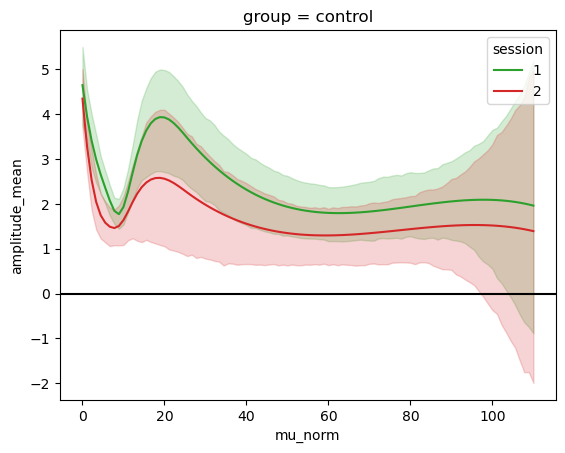

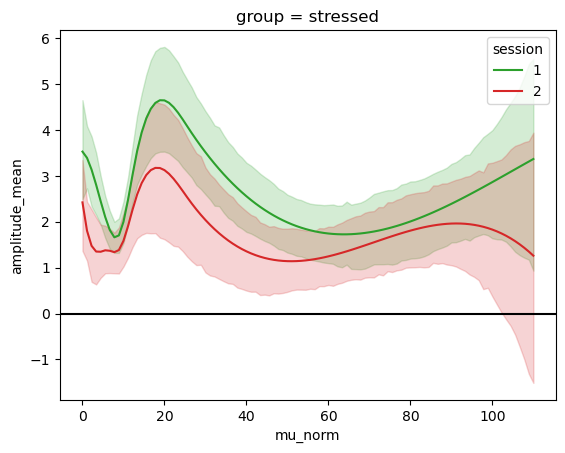

In [26]:
import matplotlib.pyplot as plt
sns.lineplot(data=predictions.xs(0,0,'group').reset_index(), x='mu_norm', y='amplitude_mean', hue='session',palette=sns.color_palette()[2:], errorbar=get_hdi)
plt.title('group = control')
plt.axhline(0, color='black')

#plt.ylim(-25, 25)
plt.figure()
sns.lineplot(data=predictions.xs(1,0,'group').reset_index(), x='mu_norm', y='amplitude_mean', hue='session',palette=sns.color_palette()[2:], errorbar=get_hdi)
plt.title('group = stressed')
plt.axhline(0, color='black')


#plt.ylim(-25, 25)

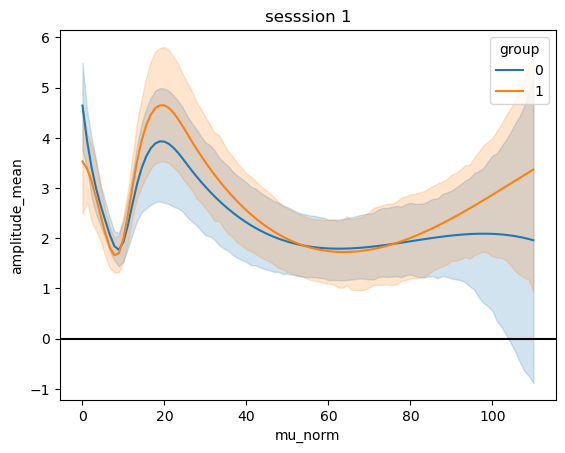

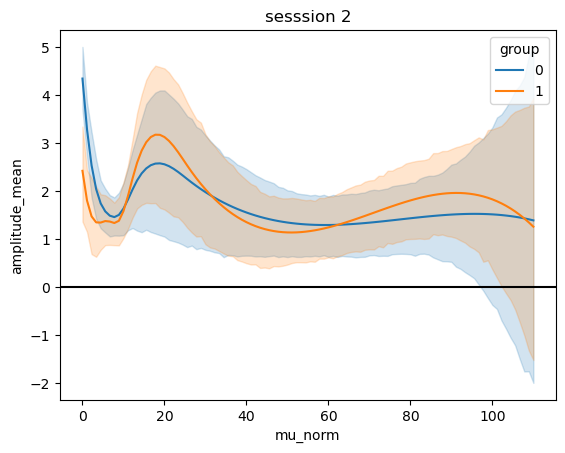

In [27]:
p = sns.lineplot(data=predictions.xs(1,0,'session').reset_index(), x='mu_norm', y='amplitude_mean', hue='group', errorbar=get_hdi)
plt.title('sesssion 1')
plt.axhline(0, color='black')


#plt.ylim(-25, 25)
plt.figure()
sns.lineplot(data=predictions.xs(2,0,'session').reset_index(), x='mu_norm', y='amplitude_mean', hue='group', errorbar=get_hdi)
plt.title('sesssion 2')
plt.axhline(0, color='black')

#plt.ylim(-25, 25)

In [32]:
# predictions.unstack(['group','session']).loc[:,('amplitude_mean',0,1)]

diff_g0 = predictions.unstack(['group','session']).loc[:,('amplitude_mean',0,2)] - predictions.unstack(['group','session']).loc[:,('amplitude_mean',0,1)]
diff_g1 = predictions.unstack(['group','session']).loc[:,('amplitude_mean',1,2)] - predictions.unstack(['group','session']).loc[:,('amplitude_mean',1,1)]

diff_g0 =diff_g0.reset_index().rename(mapper={0:'diff'},axis=1).set_index(['mu_norm', 'chain', 'draw'])
diff_g1 =diff_g1.reset_index().rename(mapper={0:'diff'},axis=1).set_index(['mu_norm', 'chain', 'draw'])


In [33]:
df_g0g1 = pd.concat([diff_g0.rename(mapper={'diff':'diff_g0'},axis=1), diff_g1.rename(mapper={'diff':'diff_g1'},axis=1)], axis=1)
df_g0g1['diff_diff'] = df_g0g1['diff_g1'] - df_g0g1['diff_g0']
df_g0g1.columns.name = 'group'
#df_g0g1 = df_g0g1.stack()#.rename(mapper={})
df_g0g1

group                diff_g0   diff_g1  diff_diff
mu_norm chain draw                               
0.0     0     0    -0.641791 -0.680260  -0.038469
              1    -0.010886  0.254289   0.265175
              2    -0.813145 -1.497221  -0.684076
              3    -0.810956 -1.527652  -0.716697
              4    -1.060403 -0.630998   0.429405
...                      ...       ...        ...
110.0   3     995  -0.956746 -4.892908  -3.936162
              996   0.216101 -3.064761  -3.280861
              997  -0.236156  1.643238   1.879394
              998   0.952753 -3.974930  -4.927683
              999  -0.563942 -0.118838   0.445104

[400000 rows x 3 columns]

(-1.0, 1.0)

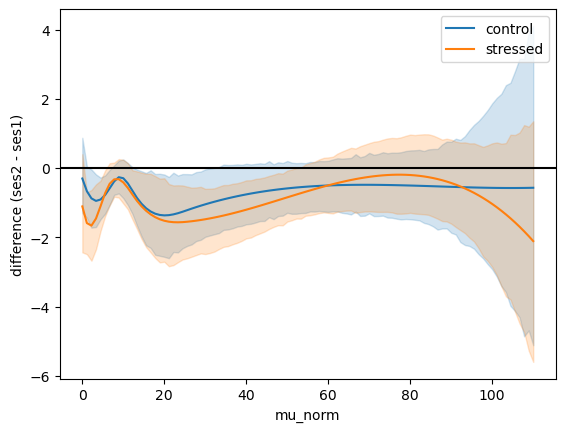

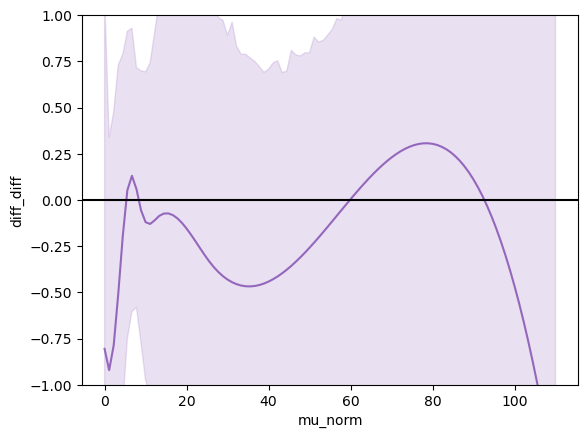

In [34]:
sns.lineplot(data=diff_g0.reset_index(), x='mu_norm', y='diff', errorbar=get_hdi, label='control')
sns.lineplot(data=diff_g1.reset_index(), x='mu_norm', y='diff', errorbar=get_hdi, label='stressed')
plt.axhline(0, color='black')
plt.ylabel('difference (ses2 - ses1)')
#plt.ylim(-1,1)

plt.figure()
sns.lineplot(data=df_g0g1, x='mu_norm', y='diff_diff', errorbar=get_hdi, color=sns.color_palette()[4])
plt.axhline(0, color='black')
plt.ylim(-1,1)


In [167]:
df = df[df['mu_norm']<110]

wp = traces.posterior['bs(mu_norm, df = 7)'].mean(("chain", "draw")).values
wp

array([-0.71340016, -1.0760335 , -1.59483571, -0.3891511 , -2.39621041,
       -0.92797439, -0.96524003])

In [181]:
num_knots = 7
knot_list = np.quantile(df.mu_norm.values, np.linspace(0, 1, num_knots))
from patsy import dmatrix
B = dmatrix(
    f"bs(mu_norm, knots=knots, degree={num_knots}, include_intercept=True) - 1",
    {"mu_norm": df.mu_norm.values, "knots": knot_list[1:-1]},
)

In [172]:
df['mu_norm'].max()

109.0

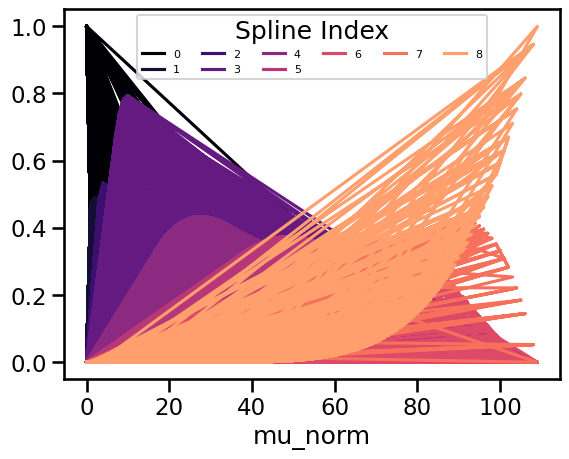

In [173]:
spline_df = (
    pd.DataFrame(B)
    .assign(mu_norm=df.mu_norm.values)
    .melt("mu_norm", var_name="spline_i", value_name="value") # Unpivot a DataFrame from wide to long format
) # see: spline_df.set_index(['year','spline_i']).unstack('spline_i')

color = plt.cm.magma(np.linspace(0, 0.80, len(spline_df.spline_i.unique())))

fig = plt.figure()
for i, c in enumerate(color):
    subset = spline_df.query(f"spline_i == {i}")
    subset.plot("mu_norm", "value", c=c, ax=plt.gca(), label=i)
plt.legend(title="Spline Index", loc="upper center", fontsize=8, ncol=6);

In [177]:
spline_df.spline_i.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=object)

In [ ]:
wp = traces.posterior['bs(mu_norm, df = 7)'].mean(("chain", "draw")).values

spline_df = (
    pd.DataFrame(B * wp.T)
    .assign(mu_norm=bdf.mu_norm.values)
    .melt("mu_norm", var_name="spline_i", value_name="value")
)

spline_df_merged = (
    pd.DataFrame(np.dot(B, wp.T))
    .assign(mu_norm=bdf.mu_norm.values)
    .melt("mu_norm", var_name="spline_i", value_name="value")
)


color = plt.cm.rainbow(np.linspace(0, 1, len(spline_df.spline_i.unique())))
fig = plt.figure()
for i, c in enumerate(color):
    subset = spline_df.query(f"spline_i == {i}")
    subset.plot("mu_norm", "value", c=c, ax=plt.gca(), label=i)
spline_df_merged.plot("mu_norm", "value", c="black", lw=2, ax=plt.gca())
plt.legend(title="Spline Index", loc="lower center", fontsize=8, ncol=6)

for knot in knot_list:
    plt.gca().axvline(knot, color="grey", alpha=0.4);

In [180]:
# repeat with voxels from both sessions selected
# repeat with unsmoothed
knot_list[1:-1]

array([ 6., 10., 18.])